# Assignment 4

Deadline: 30.04.2025 12:00 CET

<Add your name, student-id and emal address>

## Prerequisites: Library imports, data load and initialization of the backtest service

In [1]:
# Standard library imports
import os
import sys
import copy
from typing import Optional

# Third party imports
import numpy as np
import pandas as pd

# Add the project root directory to Python path
project_root = os.path.dirname(os.path.dirname(os.getcwd()))   #<Change this path if needed>
src_path = os.path.join(project_root, 'qpmwp-course//src')    #<Change this path if needed>
sys.path.append(project_root)
sys.path.append(src_path)

# Local modules imports
from helper_functions import load_data_spi, load_pickle
from estimation.covariance import Covariance
from estimation.expected_return import ExpectedReturn
from optimization.optimization import Optimization, Objective, MeanVariance
from optimization.optimization_data import OptimizationData
from optimization.constraints import Constraints
from backtesting.backtest_item_builder_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder_functions import (
    bibfn_selection_min_volume,
    bibfn_selection_gaps,
    bibfn_return_series,
    bibfn_budget_constraint,
    bibfn_box_constraints,
    bibfn_size_dependent_upper_bounds,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest

In [2]:
# Load data
path_to_data = '/home/patsias/QPM/EXERCISE/qpmwp-course/data/'  # <change this to your path to data>

# Load market and jkp data from parquet files
market_data = pd.read_parquet(path = f'{path_to_data}market_data.parquet')

# Instantiate the BacktestData class
# and set the market data and jkp data as attributes
data = BacktestData()
data.market_data = market_data
data.bm_series = load_data_spi(path='../data/')  # <change this if necessary>

In [3]:
# Define rebalancing dates
n_days = 21*3
market_data_dates = market_data.index.get_level_values('date').unique().sort_values(ascending=True)
rebdates = market_data_dates[market_data_dates > '2015-01-01'][::n_days].strftime('%Y-%m-%d').tolist()

In [4]:
market_data_dates
market_data

,,price,mktcap,liquidity,sector
date,id,,,,
1999-05-06,1,461.000000,1.235952e+09,129080.0,None
1999-05-07,1,455.000000,1.219866e+09,4550.0,None
1999-05-10,1,455.000000,1.219866e+09,910.0,None
1999-05-11,1,460.000000,1.233271e+09,4600.0,None
1999-05-12,1,460.000000,1.233271e+09,460.0,None
...,...,...,...,...,...
2024-04-24,313,9.814924,2.016783e+07,0.0,None
2024-04-25,313,9.814924,2.016783e+07,0.0,None
2024-04-26,313,9.814924,2.016783e+07,0.0,None


In [5]:
# Define the selection item builders.
selection_item_builders = {
    'gaps': SelectionItemBuilder(
        bibfn = bibfn_selection_gaps,
        width = 252*3,
        n_days = 10,
    ),
    'min_volume': SelectionItemBuilder(
        bibfn = bibfn_selection_min_volume,
        width = 252,
        min_volume = 500_000,
        agg_fn = np.median,
    ),
}

# Define the optimization item builders.
optimization_item_builders = {
    'return_series': OptimizationItemBuilder(
        bibfn = bibfn_return_series,
        width = 252*3,
        fill_value = 0,
    ),
    'budget_constraint': OptimizationItemBuilder(
        bibfn = bibfn_budget_constraint,
        budget = 1,
    ),
    'box_constraints': OptimizationItemBuilder(
        bibfn = bibfn_box_constraints,
        upper = 0.1,
    ),
    'size_dep_upper_bounds': OptimizationItemBuilder(
        bibfn = bibfn_size_dependent_upper_bounds,
        small_cap = {'threshold': 300_000_000, 'upper': 0.02},
        mid_cap = {'threshold': 1_000_000_000, 'upper': 0.05},
        large_cap = {'threshold': 10_000_000_000, 'upper': 0.1},
    ),
}

# Initialize the backtest service
bs = BacktestService(
    data = data,
    selection_item_builders = selection_item_builders,
    optimization_item_builders = optimization_item_builders,
    rebdates = rebdates,
)

## 1. Maximum Sharpe Ratio Portfolio

a) 

(6 points)

Complete the `MaxSharpe` class below by implementing your its methods `set_objective` and `solve`.
The `solve` method should implement an iterative algorithm that quickly approximates the "true" maximimum Sharpe ratio portfolio (given the estimates of mean and covariance). This approximation should be done by repeatedly solving a mean-variance optimization problem, where the risk aversion parameter (which scales the covariance matrix) is adjusted in each iteration. The algorithm should terminate after a maximum of 10 iterations. 

In [6]:
class MaxSharpe(Optimization):

    def __init__(self,
                 constraints: Optional[Constraints] = None,
                 covariance: Optional[Covariance] = None,
                 expected_return: Optional[ExpectedReturn] = None,
                 **kwargs) -> None:
        super().__init__(
            constraints=constraints,
            **kwargs,
        )
        self.covariance = Covariance() if covariance is None else covariance
        self.expected_return = ExpectedReturn() if expected_return is None else expected_return

    def set_objective(self, optimization_data: OptimizationData) -> None:
        X = optimization_data['return_series']
        self.expected_return.estimate(X)
        self.mu = self.expected_return.vector 

        # Estimate covariance matrix
        self.covariance.estimate(X)
        self.Sigma = self.covariance.matrix  

        # Store the asset IDs
        self.assets = self.mu.index.tolist()


        return None

    def solve(self) -> None:
        best_sharpe = -np.inf
        best_weights = None

        # try different risk aversion levels
        gammas = np.logspace(-3,3, num=10)

        for gamma in gammas:
            def objective(w):
                ret = np.dot(self.mu.values, w) # μ^Τw
                vol = np.dot(w, self.Sigma.values @ w) # w^TΣw
                return -(ret - (gamma / 2) * vol) # -(μ^Τw -γ/2w^TΣw)

        x0 = np.ones(len(self.assets)) / len(self.assets)

        def weight_sum_to_one(w):
            return np.sum(w) - 1

        constraints = [{
            'type': 'eq',         
            'fun':  weight_sum_to_one  
        }]

        bounds = [(0, 1) for _ in self.assets]
        from scipy.optimize import minimize
        results = minimize(objective, x0, bounds=bounds, constraints=constraints)
        if results.success:
            w = results.x
            # Calculate Sharpe ratio
            ret = np.dot(self.mu.values, w)
            vol = np.sqrt(np.dot(w, self.Sigma.values @ w))
            sharpe = ret / vol if vol != 0 else -np.inf

            if sharpe > best_sharpe:
                best_sharpe = sharpe
                best_weights = w
                best_gamma = gamma

            # Store the best weights
            self.weights = pd.Series(best_weights, index=self.assets)
            
        self.results = {
            'weights': pd.Series(best_weights, index=self.assets),
            'sharpe': best_sharpe,
            'gamma': best_gamma
        }



        return None

b) 

(2 points)

Provide a theoretical or empirical justification that your algorithm converges to the true maximum Sharpe ratio portfolio for the given coefficients of mean and covariance.
Hint: If you want to provide an empirical justification, you can perform an optimization for a single point in time by running the following code.

In [7]:
bs.optimization = MaxSharpe(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',  # <change this to your preferred solver>
    optimization_data=bs.optimization_data
)
bs.prepare_rebalancing('2015-01-02')
bs.optimization.set_objective(bs.optimization_data)
bs.optimization.solve()
bs.optimization.results

{'weights': 102    0.000000e+00
 103    0.000000e+00
 104    0.000000e+00
 111    4.222869e-03
 113    0.000000e+00
            ...     
 79     0.000000e+00
 86     1.021306e-18
 88     5.337940e-19
 91     4.445886e-19
 93     1.331590e-02
 Length: 88, dtype: float64,
 'sharpe': np.float64(0.11049790810305618),
 'gamma': np.float64(1000.0)}

## 2. Backtest MaxSharpe with Turnover Penalty

(5 points)

Calibrate the turnover penalty parameter such that the backtest of the MaxSharpe strategy displays an annual turnover of roughly 100%.

In [8]:
# Update the backtest service with a MaxSharpe optimization object
bs.optimization = MaxSharpe(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',    # <change this to your preferred solver>
    turnover_penalty=0.05,   # <change this>
)

# Instantiate the backtest object
bt_ms = Backtest()

# Run the backtest
bt_ms.run(bs = bs)


to = bt_ms.strategy.turnover(return_series=bs.data.get_return_series())
print("Average yearly turnover:", to.mean() * 12)


Rebalancing date: 2015-01-02
Rebalancing date: 2015-04-01
Rebalancing date: 2015-06-29
Rebalancing date: 2015-09-24
Rebalancing date: 2015-12-22
Rebalancing date: 2016-03-18
Rebalancing date: 2016-06-15
Rebalancing date: 2016-09-12
Rebalancing date: 2016-12-08
Rebalancing date: 2017-03-07
Rebalancing date: 2017-06-02
Rebalancing date: 2017-08-30
Rebalancing date: 2017-11-27
Rebalancing date: 2018-02-22
Rebalancing date: 2018-05-22
Rebalancing date: 2018-08-17
Rebalancing date: 2018-11-14
Rebalancing date: 2019-02-11
Rebalancing date: 2019-05-09
Rebalancing date: 2019-08-06
Rebalancing date: 2019-11-01
Rebalancing date: 2020-01-29
Rebalancing date: 2020-04-27
Rebalancing date: 2020-07-23
Rebalancing date: 2020-10-20
Rebalancing date: 2021-01-15
Rebalancing date: 2021-04-14
Rebalancing date: 2021-07-12
Rebalancing date: 2021-10-07
Rebalancing date: 2022-01-04
Rebalancing date: 2022-04-01
Rebalancing date: 2022-06-29
Rebalancing date: 2022-09-26
Rebalancing date: 2022-12-22
Rebalancing da

## 3. Simulation and Descriptive Statistics

(3 points)

- Simulate the portfolio returns from your MaxSharpe backtest. Use fixed costs of 1% and variable costs of 0.3%.
- Plot the cumulated returns of the MaxSharpe strategy together with those of the SPI Index.
- Plot the turnover of your MaxSharpe strategy over time.
- Print the annualized turnover (computed as the average turnover over the backtest multiplied by the number of rebalancing per year) for your MaxSharpe strategy.
- Create and print a table with descriptive performance statistics for your MaxSharpe strategy and the SPI Index.


/home/patsias/QPM/EXERCISE/qpmwp-course//src/backtesting/strategy.py:195: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  portf_ret[0] -= varcost[0]
/home/patsias/QPM/EXERCISE/qpmwp-course//src/backtesting/strategy.py:195: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  portf_ret[0] -= varcost[0]


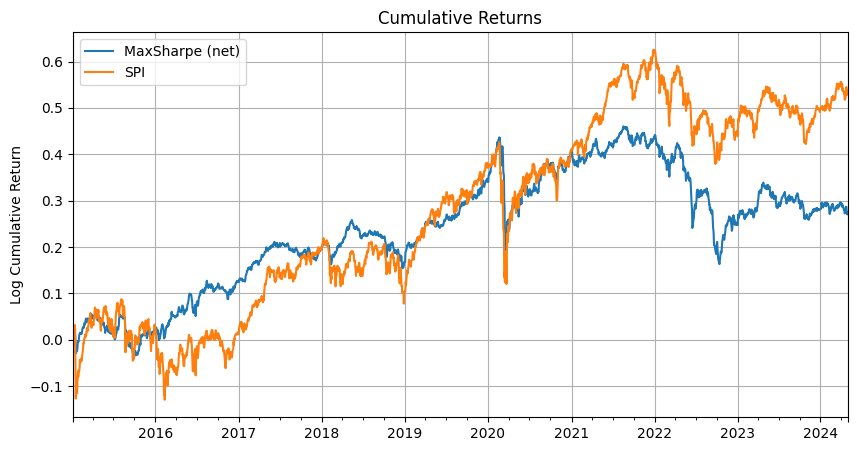

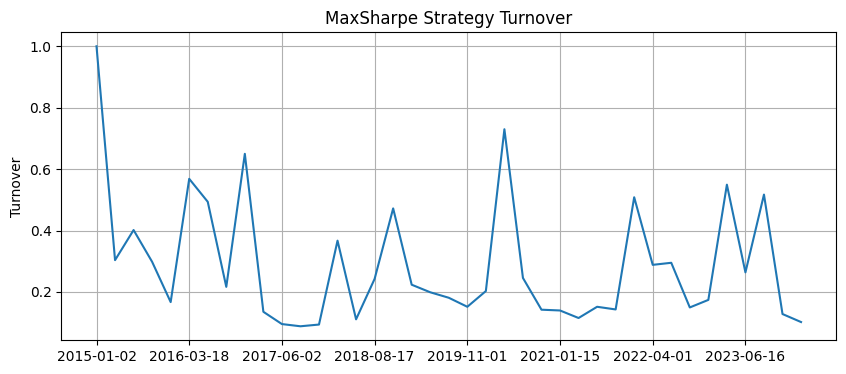

Annualized Turnover: 347.70%
                                                     Annual Return  \
MaxSharpe (net)  2015-01-05   -0.000443
2015-01-06   -0.000251
...   
SPI              2015-01-05   -0.000477
2015-01-06   -0.001175
...   

                 Cumulative Return  Annual Volatility  Sharpe Ratio  \
MaxSharpe (net)             0.3113             0.0838        0.3772   
SPI                         0.7011             0.1457        0.4511   

                 Max Drawdown  
MaxSharpe (net)       -0.2570  
SPI                   -0.2633  


In [9]:
fixed_costs = 0.01     # 1% fixed
variable_costs = 0.003 # 0.3% variable

return_series = bs.data.get_return_series()

sim_ms_net = bt_ms.strategy.simulate(
    return_series=return_series,
    fc=fixed_costs,
    vc=variable_costs
)

sim_df = pd.concat({
    'MaxSharpe (net)': sim_ms_net,
    'SPI': bs.data.bm_series
}, axis=1).dropna()


import numpy as np
import matplotlib.pyplot as plt

np.log(1 + sim_df).cumsum().plot(figsize=(10, 5), title="Cumulative Returns")
plt.ylabel("Log Cumulative Return")
plt.grid(True)
plt.show()


to_ms = bt_ms.strategy.turnover(return_series=return_series)

to_ms.plot(title="MaxSharpe Strategy Turnover", figsize=(10, 4))
plt.ylabel("Turnover")
plt.grid(True)
plt.show()


annual_turnover = to_ms.mean() * 12
print(f"Annualized Turnover: {annual_turnover:.2%}")


import empyrical as ep

# Create a dictionary to hold results
rows = {}

for name in sim_df.columns:
    series = sim_df[name].dropna()
    rows[name] = {
        'Annual Return': ep.annual_return(series),
        'Cumulative Return': ep.cum_returns_final(series),
        'Annual Volatility': ep.annual_volatility(series),
        'Sharpe Ratio': ep.sharpe_ratio(series),
        'Max Drawdown': ep.max_drawdown(series)
    }

# Build the final table
perf_table = pd.DataFrame.from_dict(rows, orient='index')
print(perf_table.round(4))
